# Examen Práctico de la UT4

**Duracion:** 1 hora

## Contexto
Una empresa de seguridad necesita automatizar el procesamiento de las tarjetas de identificacion (credenciales) de sus empleados. Por normativas de privacidad, antes de almacenar las imagenes escaneadas de las tarjetas en la base de datos, el sistema debe localizar la tarjeta en la imagen, recortarla, detectar el rostro del empleado y censurarlo (pixelarlo o cubrirlo).



## Materiales proporcionados
* `credencial_escena.png`: Una fotografia donde aparece una tarjeta de identificacion sobre una mesa con algo de ruido de fondo.
* `haarcascade_frontalface_default.xml`: Archivo pre-entrenado para la deteccion de rostros.



## Aviso Importante
Las imágenes de referencia se proporcionan para guiar tu desarrollo. Sin embargo, todo el pipeline debe ser dinámico. Se penalizará con un 0 en el ejercicio el uso de hardcoding (introducir coordenadas fijas a mano para recortar o censurar). El sistema debe ser capaz de encontrar la tarjeta y el rostro utilizando los algoritmos enseñados, independientemente de en qué píxel exacto se encuentren.

In [35]:
# Importacion de librerias necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuracion de Matplotlib para visualizar correctamente en el notebook
plt.rcParams['figure.figsize'] = (15.0, 5.0)


### Ejercicio 1: Preprocesamiento y Binarizacion (20 puntos)

1. Carga la imagen `credencial_escena.png` en escala de grises.
2. Aplica un suavizado (Gaussian Blur) para reducir el ruido.
3. Utiliza el metodo de **Binarizacion de Otsu** (con inversion si es necesario) para separar la tarjeta del fondo oscuro.
4. Aplica una operacion de **Morfologia Matematica** (Cierre o Apertura) para eliminar pequenos ruidos del fondo y rellenar huecos dentro de la tarjeta binarizada.

In [36]:
img_bgr = cv2.imread("./credencial_escena.png")
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
img_thresh_otsu = cv2.threshold(img_blur, 0, 255, cv2.THRESH_OTSU)
kernel = np.ones([3,3])
img_open = cv2.morphologyEx(img_thresh_otsu[1], cv2.MORPH_OPEN, kernel)

### Ejercicio 2: Geometria y Contornos (30 puntos)

1. Encuentra los contornos en la imagen binarizada resultante del paso anterior.
2. Filtra los contornos y quedate unicamente con el contorno de mayor area (que correspondera a la credencial).
3. Calcula el *Bounding Box* recto (`cv2.boundingRect`) de ese contorno.
4. Utilizando las coordenadas obtenidas, haz un recorte (*Slicing* / ROI) de la imagen original a color para obtener una nueva imagen que contenga **solo la credencial**.

In [37]:
contours, hierarchy = cv2.findContours(img_open, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img_bgr.copy()
min_area = 100000

filtered_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > min_area:
        filtered_contours.append(cnt)

imagenes = []

for i, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    imagen = img_bgr[y:y+h, x:x+w]
    imagenes.append(imagen)

if len(imagenes) > 1:
    print("Se encontraron más de 2 tarjetas, muestre solo 1 tarjeta")
else:
    recorte_tarjeta = imagenes[0]

### Ejercicio 3: Deteccion de Rostros y Anonimizacion (35 puntos)

1. Carga el clasificador en cascada de Haar para rostros frontales.
2. Pasa la imagen de la credencial recortada a escala de grises y detecta el rostro del empleado en ella.
3. Una vez obtenidas las coordenadas del rostro `(x, y, w, h)`:
   * Extrae la region de interes (ROI) del rostro en la credencial a color.
   * Aplica un difuminado extremo (ej. `cv2.blur` con un kernel muy grande, como 25x25) sobre esa ROI.
   * Sustituye la ROI procesada en la imagen de la credencial original.

In [38]:
modelo_caras = cv2.CascadeClassifier('./haarcascade_frontalface_default.xml')
recorte_tarjeta_gray = cv2.cvtColor(recorte_tarjeta, cv2.COLOR_BGR2GRAY)
deteccion_caras = modelo_caras.detectMultiScale(recorte_tarjeta_gray, 1.1, 5, minSize= (30, 30))
recorte_tarjeta_copy = recorte_tarjeta.copy()
for (x, y, w, h) in deteccion_caras:
    recorte_cara = recorte_tarjeta_copy[y:y+h, x:x+w]
    recorte_cara_blur = cv2.blur(recorte_cara, (25, 25))
    recorte_tarjeta_copy[y:y+h, x:x+w] = recorte_cara_blur
    recorte_tarjeta_blur = recorte_tarjeta_copy

### Ejercicio 4: Visualizacion del Pipeline (15 puntos)

Crea un unico *plot* de Matplotlib con 1 fila y 3 columnas que muestre de forma clara el flujo de trabajo:
1. **Columna 1:** Imagen original binarizada (Resultado Ejercicio 1).
2. **Columna 2:** La credencial aislada y recortada a color (Resultado Ejercicio 2).
3. **Columna 3:** La credencial final con el rostro anonimizado (Resultado Ejercicio 3).

*(Recuerda realizar las conversiones BGR a RGB necesarias para que los colores se muestren correctamente en Matplotlib).*

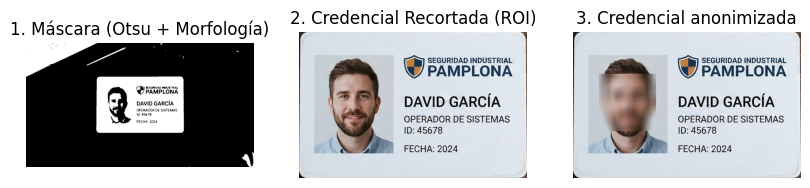

In [39]:
plt.figure(figsize=(10,6))
plt.subplot(1, 3, 1)
plt.title("1. Máscara (Otsu + Morfología)")
plt.imshow(cv2.cvtColor(img_open, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Credencial Recortada (ROI)")
plt.imshow(cv2.cvtColor(recorte_tarjeta, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Credencial anonimizada")
plt.imshow(cv2.cvtColor(recorte_tarjeta_blur, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()